In [1]:
import pandas as pd

df = pd.read_csv("../datasets/clean_reviews.csv")

df.shape

C:\Users\d_fon\AppData\Local\Temp\ipykernel_25736\3563623075.py:3: DtypeWarning: Columns (1: name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../datasets/clean_reviews.csv")


(34615, 19)

- train/test/split

In [2]:
X = df["reviews.text"]
y = df["sentiment"]

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 27692
Test samples: 6923


In [6]:
print("TRAIN:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTEST:")
print(y_test.value_counts(normalize=True) * 100)

TRAIN:
sentiment
positive    93.330204
neutral      4.329770
negative     2.340026
Name: proportion, dtype: float64

TEST:
sentiment
positive    93.326593
neutral      4.333381
negative     2.340026
Name: proportion, dtype: float64


- tf-idf 

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [8]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

In [9]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [10]:
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (27692, 10000)
Test TF-IDF shape: (6923, 10000)


In [11]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names[:50])

Number of features: 10000
['00' '10' '10 and' '10 year' '100' '1080p' '11' '11 year' '12' '12 year'
 '128' '128gb' '13' '14' '15' '16' '16gb' '18' '1st' '1st gen'
 '1st generation' '20' '200' '2015' '2016' '25' '2nd' '2nd one' '30' '300'
 '32' '32gb' '33' '34' '35' '35 on' '39' '39 99' '3g' '3rd' '3rd kindle'
 '3rd party' '40' '49' '49 99' '4k' '4k and' '4k content' '4k is'
 '4k streaming']


In [12]:
[word for word in feature_names if "good" in word][:20]

['all good',
 'also good',
 'and good',
 'are good',
 'as good',
 'be good',
 'been good',
 'but good',
 'for good',
 'good',
 'good and',
 'good as',
 'good at',
 'good battery',
 'good but',
 'good buy',
 'good choice',
 'good deal',
 'good device',
 'good enough']

- linear svc

In [13]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

In [14]:
svm_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [15]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [16]:
from sklearn.metrics import accuracy_score, classification_report

print("Linear SVM Accuracy:")
print(accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy:
0.9352881698685541

Classification Report:
              precision    recall  f1-score   support

    negative       0.50      0.23      0.32       162
     neutral       0.37      0.11      0.17       300
    positive       0.95      0.99      0.97      6461

    accuracy                           0.94      6923
   macro avg       0.60      0.45      0.49      6923
weighted avg       0.91      0.94      0.92      6923



- bag of words

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

In [18]:
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [19]:
print("Train BoW shape:", X_train_bow.shape)
print("Test BoW shape:", X_test_bow.shape)

Train BoW shape: (27692, 10000)
Test BoW shape: (6923, 10000)


- bag of words + linear svc

In [20]:
svm_bow = LinearSVC(
    random_state=42
)

svm_bow.fit(X_train_bow, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [21]:
y_pred_svm_bow = svm_bow.predict(X_test_bow)

In [22]:
print("Linear SVM + Bag of Words Accuracy:")
print(accuracy_score(y_test, y_pred_svm_bow))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_bow))

Linear SVM + Bag of Words Accuracy:
0.9172324136934855

Classification Report:
              precision    recall  f1-score   support

    negative       0.40      0.28      0.33       162
     neutral       0.23      0.20      0.21       300
    positive       0.95      0.97      0.96      6461

    accuracy                           0.92      6923
   macro avg       0.53      0.48      0.50      6923
weighted avg       0.91      0.92      0.91      6923



- linea  svc + bag of words + tf idf

In [23]:
from scipy.sparse import hstack

X_train_combined = hstack([X_train_tfidf, X_train_bow])

X_test_combined = hstack([X_test_tfidf, X_test_bow])

print("Combined Train:", X_train_combined.shape)
print("Combined Test:", X_test_combined.shape)

Combined Train: (27692, 20000)
Combined Test: (6923, 20000)


In [24]:
svm_combined = LinearSVC(random_state=42)

svm_combined.fit(X_train_combined, y_train)

y_pred_combined = svm_combined.predict(X_test_combined)

In [25]:
print("Linear SVM + TF-IDF + BoW Accuracy:")
print(accuracy_score(y_test, y_pred_combined))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_combined))

Linear SVM + TF-IDF + BoW Accuracy:
0.9172324136934855

Classification Report:
              precision    recall  f1-score   support

    negative       0.41      0.30      0.34       162
     neutral       0.23      0.20      0.21       300
    positive       0.95      0.97      0.96      6461

    accuracy                           0.92      6923
   macro avg       0.53      0.49      0.50      6923
weighted avg       0.91      0.92      0.91      6923



In [26]:
svm_balanced = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_balanced.fit(X_train_tfidf, y_train)

y_pred_balanced = svm_balanced.predict(X_test_tfidf)

print("Balanced Linear SVM + TF-IDF Accuracy:")
print(accuracy_score(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Balanced Linear SVM + TF-IDF Accuracy:
0.9232991477683086

Classification Report:
              precision    recall  f1-score   support

    negative       0.47      0.40      0.43       162
     neutral       0.29      0.28      0.28       300
    positive       0.96      0.97      0.96      6461

    accuracy                           0.92      6923
   macro avg       0.57      0.55      0.56      6923
weighted avg       0.92      0.92      0.92      6923



- confusion matrix

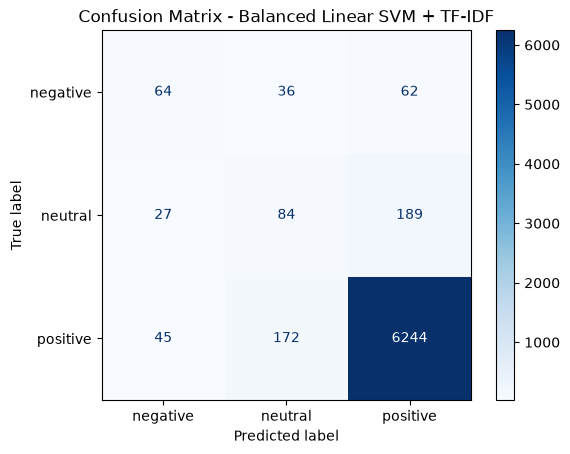

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced, cmap="Blues")

plt.title("Confusion Matrix - Balanced Linear SVM + TF-IDF")
plt.show()

In [28]:
from sklearn.linear_model import LogisticRegression

logreg_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logreg_balanced.fit(X_train_tfidf, y_train)

y_pred_logreg_balanced = logreg_balanced.predict(X_test_tfidf)

print("Balanced Logistic Regression + TF-IDF Accuracy:")
print(accuracy_score(y_test, y_pred_logreg_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg_balanced))

Balanced Logistic Regression + TF-IDF Accuracy:
0.859742886032067

Classification Report:
              precision    recall  f1-score   support

    negative       0.31      0.59      0.41       162
     neutral       0.17      0.43      0.25       300
    positive       0.98      0.89      0.93      6461

    accuracy                           0.86      6923
   macro avg       0.49      0.63      0.53      6923
weighted avg       0.93      0.86      0.89      6923



## Final Conclusions — Sentiment Analysis

The goal of this task was to classify customer reviews into three sentiment classes based on their textual content:

- Negative: ratings 1–2
- Neutral: rating 3
- Positive: ratings 4–5

### Approach

The cleaned review text was used as the input feature and the sentiment label derived from the rating was used as the target.

The dataset was split into training and test sets using stratified sampling to preserve the original class distribution.

Text was transformed into numerical features using TF-IDF and Bag of Words with unigrams and bigrams.

Several traditional machine learning approaches were tested:

- Logistic Regression + TF-IDF
- Naive Bayes + TF-IDF
- Linear SVM + TF-IDF
- Linear SVM + Bag of Words
- Linear SVM + combined TF-IDF and Bag of Words
- Linear SVM + TF-IDF with class balancing
- Logistic Regression + TF-IDF with class balancing

### Class Imbalance

One of the main challenges was the strong class imbalance in the dataset.

Approximately 93% of the reviews were classified as positive, while neutral and negative reviews represented only a small percentage of the data.

Because of this imbalance, accuracy alone was not considered sufficient to evaluate model performance.

Precision, Recall, F1-score, Macro F1 and the confusion matrix were also analyzed, with particular attention to the minority classes.

### Model Comparison

Most models achieved high overall accuracy because of the dominance of positive reviews.

The baseline Logistic Regression model achieved approximately 93.6% accuracy and performed very well on the positive class, but performance on negative and neutral reviews was significantly weaker.

Naive Bayes showed similar overall accuracy but was unable to effectively identify the minority classes.

Linear SVM achieved approximately 93.5% accuracy and improved minority-class detection compared with the other baseline models.

Class balancing improved the ability of the models to identify negative and neutral reviews. In particular, the balanced Linear SVM achieved a Macro F1 of approximately 0.56, although this came with a small reduction in overall accuracy.

### Final Model

Balanced Linear SVM with TF-IDF was selected as the final sentiment classification model.

It provides the strongest balanced performance in the tested models, with Macro F1 and minority-class recall prioritized over raw accuracy. LinearSVC does not provide `predict_proba()` directly, so any future confidence display requires a separate calibrated decision-score approach rather than silently replacing the model.

Its simplicity also makes it suitable for deployment and interpretation within the scope of this project.

### Key Findings

- Customer feedback is overwhelmingly positive.
- High accuracy does not necessarily mean strong performance across all sentiment classes.
- Negative and neutral reviews are considerably more difficult to classify because they contain far fewer training examples.
- TF-IDF provided an effective representation of the review text for traditional machine learning models.
- Class balancing improved minority-class recall but introduced a trade-off between minority-class performance and overall accuracy.
- Model selection therefore depends on the objective: maximizing overall accuracy or improving performance across all sentiment classes.

### Limitations

The main limitation of the sentiment classifier is the severe class imbalance.

Because positive reviews dominate the dataset, the model has substantially more information available to learn the positive class than the negative and neutral classes.

As a result, the final balanced Linear SVM makes a deliberate trade-off: lower overall accuracy in exchange for more reliable identification of minority sentiments.

Future improvements could include additional minority-class data, resampling techniques, class weighting, threshold optimization, or transformer-based language models.

Overall, the sentiment analysis provides a practical baseline for automatically classifying customer feedback and can now be integrated into the final web application.